In [2]:
import sys
!{sys.executable} -m pip install arviz

In [14]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


The values are expected to drop to 0. 

For further runs, we tweak the parameters


In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import pyro
import pyro.infer as infer
from pyro.infer import MCMC, NUTS

def enforce_reproducibility(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

In [8]:
import os
import sys
import arviz as az
import  matplotlib.pyplot as plt
#current folder path
current_notebook_dir = os.getcwd()
#find parent folder one level up
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, ".."))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)
    print(f"Successfully added project root to path: {project_root_dir}")

from src.model import PhylogeneticPrior
from src.diagnostics import (
    evaluate_test_diagnostics,
    print_diagnostic_report,
    compute_nj_residual
)
from src.penalty import get_fresh_test_quartets


# Run 1: Unconstrained baseline $\lambda_4=0 , \lambda_g = 0$

In [9]:
#clear old Pyro parameter traces and reset the seeds fresh
pyro.clear_param_store()
enforce_reproducibility(42)


params = {
    "N" : 50,
    "K" : 2,
    "B_train" : 500,
    "B_test" : 1000, 
    "tau" : 0.05,   
    "sigma_u" : 1.0,  
    "warmup_steps" : 300, 
    "num_samples" : 500,  
    "target_accept_prob" : 0.80,
    "seed" : 42
}

#guassian prior
# prior model represents the base object, the framework
prior_model = PhylogeneticPrior(
    N= params ["N"],
    K=params ["K"],
    B= params["B_train"],
    sigma_u=params["sigma_u"],
    seed = params["seed"]
)
print("Prior model parameters are:", prior_model)

#fresh test quartets for validation from function in penalty file
test_quartets = get_fresh_test_quartets(
    N= params ["N"],
    B_test = params["B_test"],
    train_quartets=prior_model.fixed_indices,
    seed = 123
)

def global_model_conditioned(current_lmbda):
    """Global wrapper function visible to multiprocessing child workers."""
    return prior_model.initialize(
        lmbda_4=current_lmbda,
        lmbda_g=0.0,
        tau=params["tau"],
        use_scale=False  # to isolate lambda sweep
    )


#lambda grid for test run
lambda_grid = [0.0, 1.0, 1.5, 2.0, 2.5, 3.0, 5.0, 10.0]
results_phase1_l4= {}


Prior model parameters are: <src.model.PhylogeneticPrior object at 0x142225610>


 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 0.0 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [00:05, 143.87it/s, step size=4.89e-01, acc. prob=0.801]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [00:06, 131.57it/s, step size=4.62e-01, acc. prob=0.852]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0017
  └─ Minimum Bulk ESS (Higher is better): 745.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0837
  └─ 95th Percentile (q_0.95): 0.2654
  └─ 99th Percentile         : 0.3131

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 34.68%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3785
  └─ 5th Percentile Gap      : 0.0318
  └─ Star-like Fraction (≤γ) : 7.82%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0034
  └─ Median Pairwise Dist    : 0.9612
  └─ Maximum Pairwise Dist   : 3.5732

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 198.108%


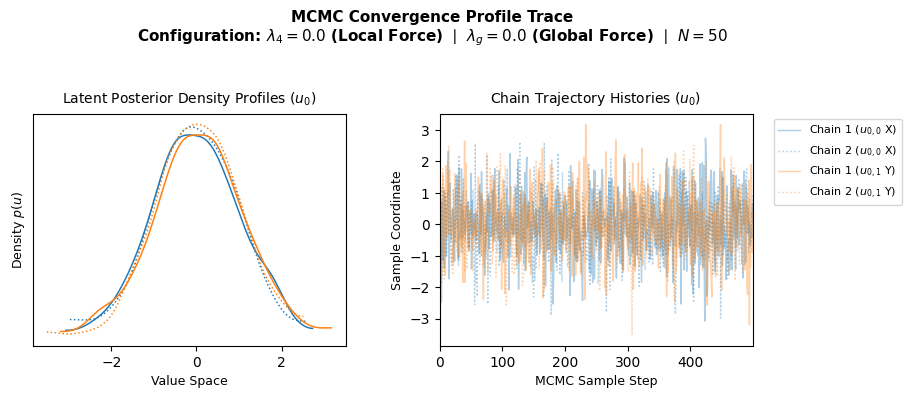

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 1.0 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [00:51, 15.59it/s, step size=1.22e-01, acc. prob=0.856]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [00:48, 16.40it/s, step size=1.27e-01, acc. prob=0.850]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0027
  └─ Minimum Bulk ESS (Higher is better): 585.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0734
  └─ 95th Percentile (q_0.95): 0.2349
  └─ 99th Percentile         : 0.2761

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 38.41%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3329
  └─ 5th Percentile Gap      : 0.0274
  └─ Star-like Fraction (≤γ) : 9.08%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0013
  └─ Median Pairwise Dist    : 0.9612
  └─ Maximum Pairwise Dist   : 3.5435

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 182.220%


Warmup:  23%|██▎       | 187/800 [05:14,  1.68s/it, step size=2.44e-01, acc. prob=0.777]


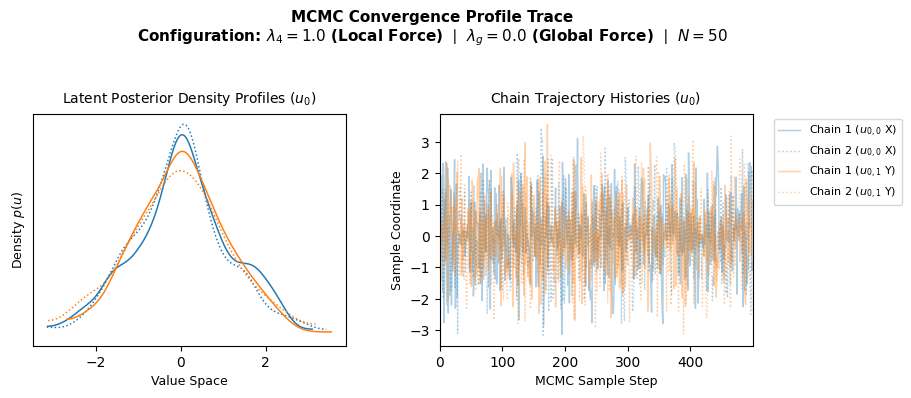

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 1.5 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [01:33,  8.51it/s, step size=9.82e-02, acc. prob=0.787]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [01:25,  9.34it/s, step size=8.21e-02, acc. prob=0.835]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0024
  └─ Minimum Bulk ESS (Higher is better): 824.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0692
  └─ 95th Percentile (q_0.95): 0.2258
  └─ 99th Percentile         : 0.2682

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 40.03%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3193
  └─ 5th Percentile Gap      : 0.0257
  └─ Star-like Fraction (≤γ) : 9.51%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0006
  └─ Median Pairwise Dist    : 0.9545
  └─ Maximum Pairwise Dist   : 3.3921

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 178.568%


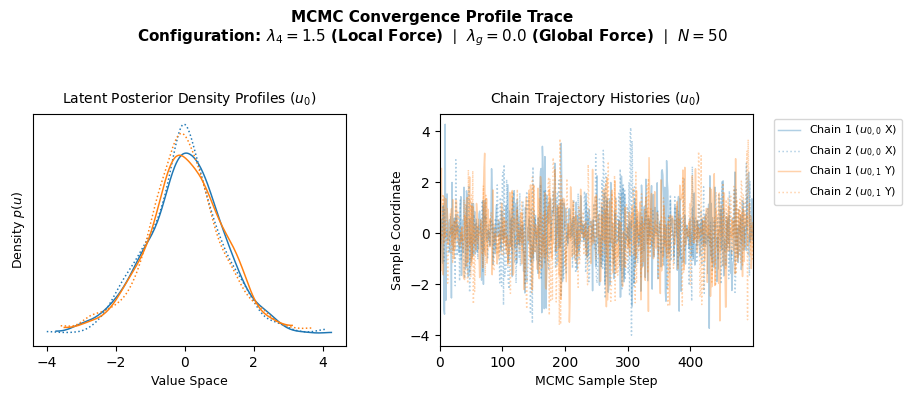

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 2.0 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [01:40,  7.92it/s, step size=6.37e-02, acc. prob=0.843]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [01:42,  7.84it/s, step size=7.66e-02, acc. prob=0.794]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0028
  └─ Minimum Bulk ESS (Higher is better): 714.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0665
  └─ 95th Percentile (q_0.95): 0.2181
  └─ 99th Percentile         : 0.2583

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 41.07%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.3017
  └─ 5th Percentile Gap      : 0.0247
  └─ Star-like Fraction (≤γ) : 9.99%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0029
  └─ Median Pairwise Dist    : 0.9601
  └─ Maximum Pairwise Dist   : 3.4108

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 170.987%


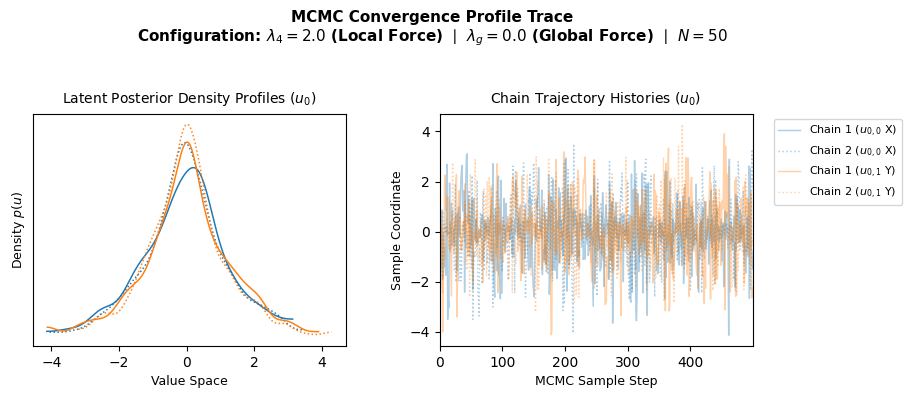

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 2.5 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [02:03,  6.49it/s, step size=5.95e-02, acc. prob=0.799]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [02:50,  4.70it/s, step size=5.05e-02, acc. prob=0.826]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0029
  └─ Minimum Bulk ESS (Higher is better): 484.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0638
  └─ 95th Percentile (q_0.95): 0.2122
  └─ 99th Percentile         : 0.2521

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 42.32%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2931
  └─ 5th Percentile Gap      : 0.0236
  └─ Star-like Fraction (≤γ) : 10.45%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0029
  └─ Median Pairwise Dist    : 0.9563
  └─ Maximum Pairwise Dist   : 3.3955

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 168.082%


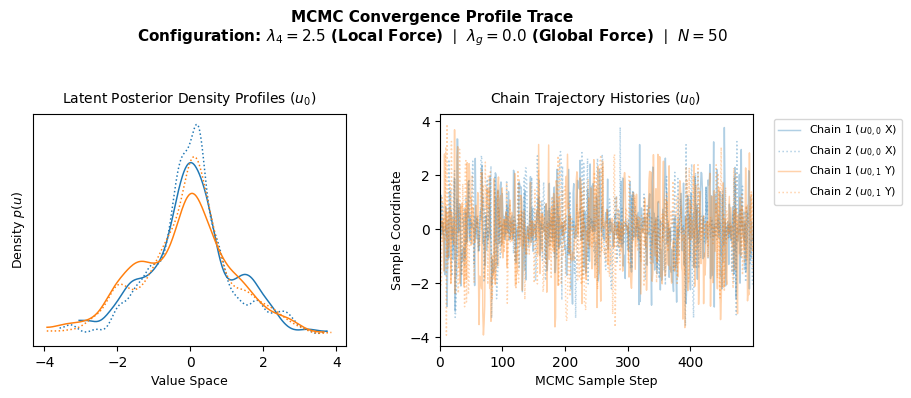

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 3.0 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [03:01,  4.42it/s, step size=4.66e-02, acc. prob=0.789]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [03:21,  3.98it/s, step size=4.00e-02, acc. prob=0.821]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0033
  └─ Minimum Bulk ESS (Higher is better): 542.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0609
  └─ 95th Percentile (q_0.95): 0.2053
  └─ 99th Percentile         : 0.2453

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.60%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2783
  └─ 5th Percentile Gap      : 0.0222
  └─ Star-like Fraction (≤γ) : 10.96%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0002
  └─ Median Pairwise Dist    : 0.9548
  └─ Maximum Pairwise Dist   : 3.6660

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 159.688%


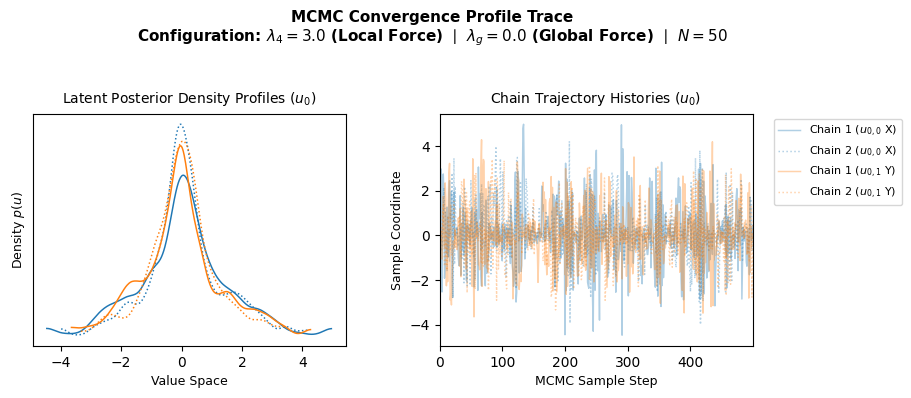

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 5.0 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [05:23,  2.47it/s, step size=2.49e-02, acc. prob=0.838]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [05:44,  2.32it/s, step size=2.49e-02, acc. prob=0.803]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0063
  └─ Minimum Bulk ESS (Higher is better): 384.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0538
  └─ 95th Percentile (q_0.95): 0.1897
  └─ 99th Percentile         : 0.2311

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 47.65%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2395
  └─ 5th Percentile Gap      : 0.0186
  └─ Star-like Fraction (≤γ) : 12.98%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0028
  └─ Median Pairwise Dist    : 0.9634
  └─ Maximum Pairwise Dist   : 3.6029

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 140.977%


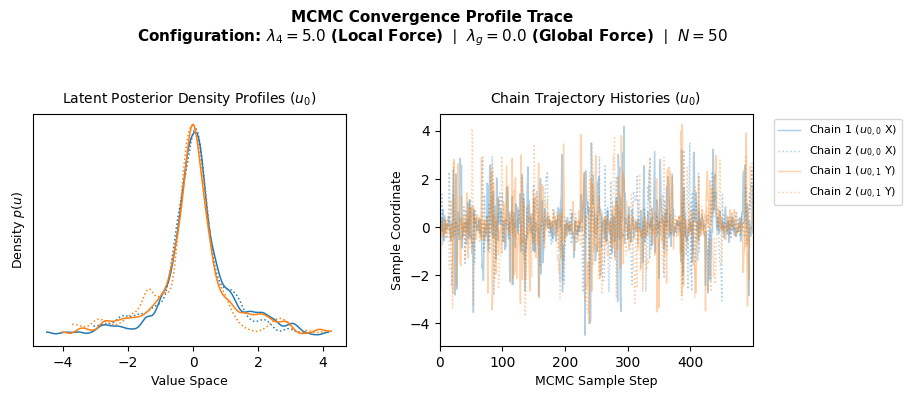

 EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = 10.0 λg =0.0  (N=50)
 Running Chain 1/2...


Sample: 100%|██████████| 800/800 [21:29,  1.61s/it, step size=2.21e-02, acc. prob=0.709]


 Running Chain 2/2...


Sample: 100%|██████████| 800/800 [10:23,  1.28it/s, step size=1.82e-02, acc. prob=0.766]


Merging sequential chains and calculating ArviZ convergence diagnostics...
  └─ Mean R-hat (Target ≤ 1.05): 1.0151
  └─ Minimum Bulk ESS (Higher is better): 74.0
DEBUG: Confirmed D_samples shape is: torch.Size([150, 50, 50])
Analyzing 150 stable sample distance representations...

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0390
  └─ 95th Percentile (q_0.95): 0.1652
  └─ 99th Percentile         : 0.2204

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 58.28%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.1641
  └─ 5th Percentile Gap      : 0.0120
  └─ Star-like Fraction (≤γ) : 19.30%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0003
  └─ Median Pairwise Dist    : 0.9789
  └─ Maximum Pairwise Dist   : 4.2089

  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 92.771%


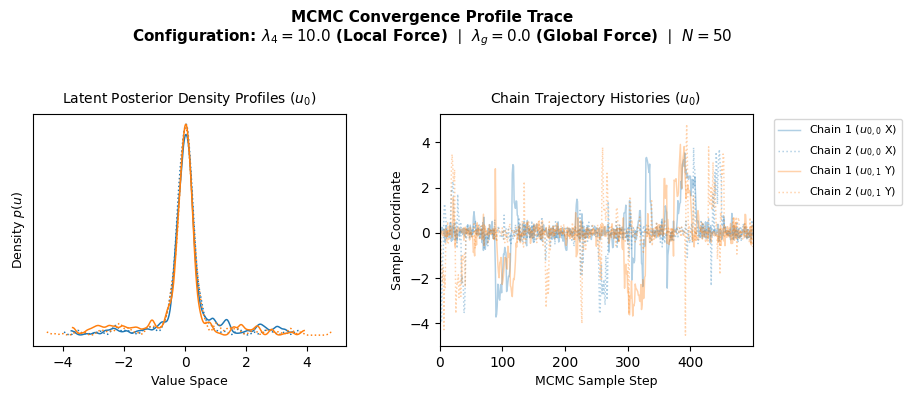

In [ ]:
# Running high-dimensional test run
for lmbda in lambda_grid:
    print(f" EXPERIMENT 1 : Phase 1 (Sequential 2-Chain sweep ): λ4 = {lmbda} λg =0.0  (N={params['N']})")
    
    def model_conditioned(current_lmbda=lmbda):
        return prior_model.initialize(
            lmbda_4=current_lmbda,
            lmbda_g=0.0,
            tau=params["tau"],
            use_scale=False
        )

    # We will collect the individual chain traces here
    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # 🎯 MANUALLY RUN 2 CHAINS SEQUENTIALLY TO BYPASS MULTIPROCESSING ENTIRELY
    for chain_idx in range(2):
        print(f" Running Chain {chain_idx + 1}/2...")
        
        # Vary seed slightly per chain to ensure independent starting trajectories
        enforce_reproducibility(params["seed"] + chain_idx)

        nuts_kernel = NUTS(model_conditioned, adapt_step_size=True, target_accept_prob=params["target_accept_prob"])
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  
        )
        
        mcmc.run()
        
        # Convert this single chain trace to ArviZ
        chain_idata = az.from_pyro(mcmc, log_likelihood=False)
        chain_idatas.append(chain_idata)
        
        # Accumulate posterior samples and diagnostics safely
        all_posterior_samples.append(mcmc.get_samples())

        # Extract the divergences container safely (handling default fallback to empty list)
        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):  # Fallback insurance for varying Pyro builds
            total_divergences += len(div_list.get("chain 0", []))
        else:
             total_divergences += len(div_list) if div_list is not None else 0

    #  COMBINE THE CHAINS MANUALLY FOR MULTI-CHAIN ARVIZ METRICS
    print("Merging sequential chains and calculating ArviZ convergence diagnostics...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"  └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"  └─ Minimum Bulk ESS (Higher is better): {min_ess_bulk:.1f}")

    # Combine distance matrices calculations across both collected spaces
    D_samples_list = []
    
    # Process 75 sample indices from each chain to get our 150 well-spaced draws
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                    
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"Landscape Failure: Complete numerical overflow at λ4 = {lmbda}")
        results_phase1_l4[lmbda] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])
    
    print(f"DEBUG: Confirmed D_samples shape is: {D_samples.shape}")

    # Run post-hoc diagnostics from your modules
    print(f"Analyzing {D_samples.shape[0]} stable sample distance representations...")
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"  └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Archive into the final multi-chain results storage ledger
    results_phase1_l4[lmbda] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }

    #trace plot
    axes_grid = az.plot_trace(
        idata, 
        var_names=["u"], 
        coords={"u_dim_0": [0], "u_dim_1": [0, 1]},
        compact=True,
        backend_kwargs={"figsize": (10, 4)}
    )
    
    # Flatten the native layout safely into a simple list
    axes = axes_grid.flatten()
    
    # 2. Left Panel: Probability Density
    axes[0].set_title(r"Latent Posterior Density Profiles ($u_{0}$)", fontsize=10, pad=8)
    axes[0].set_xlabel("Value Space", fontsize=9, labelpad=4)
    axes[0].set_ylabel(r"Density $p(u)$", fontsize=9, labelpad=4)
    
    # Right Panel: Trajectory History (Fuzzy Caterpillar)
    axes[1].set_title(r"Chain Trajectory Histories ($u_{0}$)", fontsize=10, pad=8)
    axes[1].set_xlabel("MCMC Sample Step", fontsize=9, labelpad=4)
    axes[1].set_ylabel("Sample Coordinate", fontsize=9, labelpad=4)
    
    # Move the legend box safely outside the right margin of the trajectory plot
    axes[1].legend(
        labels=[
            r"Chain 1 ($u_{0,0}$ X)", r"Chain 2 ($u_{0,0}$ X)",
            r"Chain 1 ($u_{0,1}$ Y)", r"Chain 2 ($u_{0,1}$ Y)"
        ],
        loc="upper left", 
        bbox_to_anchor=(1.05, 1.0), 
        fontsize=8,
        frameon=True,
        facecolor="white",
        edgecolor="0.8"
    )
       
    # 3. Fetch the master figure container directly from the axis object
    fig = axes[0].get_figure()
    
    # Position the main configuration overhead header cleanly
    fig.suptitle(
        fr"MCMC Convergence Profile Trace" + "\n" +
        fr"Configuration: $\lambda_4 = {lmbda}$ (Local Force) $\mid$ $\lambda_g = 0.0$ (Global Force) $\mid$ $N = {params['N']}$", 
        y=1.02, 
        fontsize=11, 
        weight='bold'
    )
    
    # Manually allocate canvas percentages to leave a clear runway for the legend
    fig.subplots_adjust(top=0.76, bottom=0.18, left=0.10, right=0.82, wspace=0.30)
    plt.show()

## Geometric profile vs $\lambda_4$

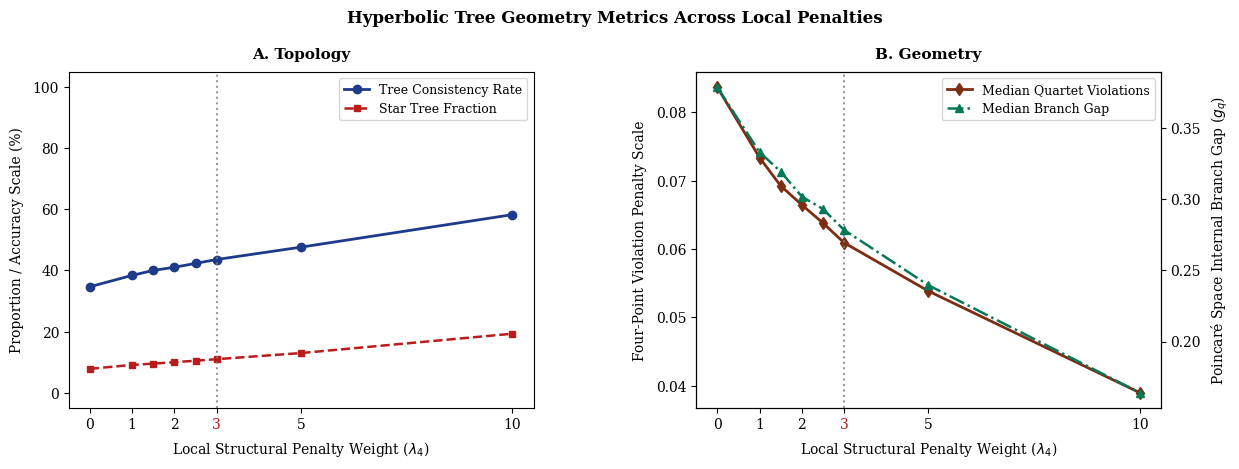

In [49]:
# =========================================================================
# 📊 HYPERBOLIC TREE GEOMETRICS VS. REGULARIZATION PROFILE
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np

# Set font family to match standard LaTeX serif rendering natively
plt.rcParams['font.family'] = 'serif'

# 1. Gather and sort the lambda grid keys from your successful runs
sorted_lambdas = sorted([k for k in results_phase1_l4.keys()])

plot_lambdas = []
consistency_rates = []
star_fractions = []
median_violations = []
branch_gaps = []

# Extract data objects matching the precise dictionary schema inside diagnostics.py
for lmb in sorted_lambdas:
    res = results_phase1_l4[lmb]
    m = res.get("metrics")
    
    # Safeguard against any complete landscape execution failures
    if m is None:
        continue
        
    plot_lambdas.append(lmb)
    
    # [A] Percentage-scale topological metrics (converting 0.0-1.0 ratios to 0-100%)
    consistency_rates.append(m.get("tree_consistency_rate", 0.0) * 100)
    
    if "quartet_gap" in m:
        star_fractions.append(m["quartet_gap"].get("unresolved_fraction", 0.0) * 100)
        branch_gaps.append(m["quartet_gap"].get("median", 0.0))
    else:
        star_fractions.append(0.0)
        branch_gaps.append(0.0)
        
    # [B] Continuous scale metric violations from diagnostics.py schema
    if "hard_violations" in m:
        median_violations.append(m["hard_violations"].get("median", 0.0))
    else:
        median_violations.append(0.0)

# 2. Initialize the 1x2 horizontal dashboard canvas
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(13, 4.8))

# ─────────────────────────────────────────────────────────────────────────
# PANEL 1: TOPOLOGY (PERCENTAGE RATIOS)
# ─────────────────────────────────────────────────────────────────────────
ax1.plot(plot_lambdas, consistency_rates, marker='o', color='#1e3a8a', linewidth=2, markersize=6, label="Tree Consistency Rate")
ax1.plot(plot_lambdas, star_fractions, marker='s', color='#b91c1c', linewidth=1.8, linestyle='--', markersize=5, label="Star Tree Fraction")

ax1.set_title("A. Topology", fontsize=11, weight='bold', pad=10)
ax1.set_xlabel(r"Local Structural Penalty Weight ($\lambda_4$)", fontsize=10, labelpad=6)
ax1.set_ylabel("Proportion / Accuracy Scale (%)", fontsize=10, labelpad=6)
ax1.set_ylim(-5, 105)
ax1.legend(loc="best", fontsize=9, frameon=True, facecolor="white", edgecolor="0.8")

# Keep ONLY the structural milestone marker at lambda=3.0
ax1.axvline(x=3.0, color='gray', linestyle=':', alpha=0.8, linewidth=1.5)

# ─────────────────────────────────────────────────────────────────────────
# PANEL 2: GEOMETRY (DUAL SCALE CONFIGURATION)
# ─────────────────────────────────────────────────────────────────────────
# Primary Axis: Quartet Violations
color_viol = '#7c2d12'
ax2.plot(plot_lambdas, median_violations, marker='d', color=color_viol, linewidth=2, markersize=6, label="Median Quartet Violations")
ax2.set_xlabel(r"Local Structural Penalty Weight ($\lambda_4$)", fontsize=10, labelpad=6)
ax2.set_ylabel("Four-Point Violation Penalty Scale",  fontsize=10, labelpad=6)
ax2.tick_params(axis='y')

# Secondary Twin Axis: Internal Resolution Gaps
ax2_twin = ax2.twinx()
color_gap = '#047857'
ax2_twin.plot(plot_lambdas, branch_gaps, marker='^', color=color_gap, linewidth=1.8, linestyle='-.', markersize=6, label="Median Branch Gap")
ax2_twin.set_ylabel(r"Poincaré Space Internal Branch Gap ($g_q$)", fontsize=10, labelpad=6)
ax2_twin.tick_params(axis='y')

# Keep ONLY the structural milestone marker at lambda=3.0
ax2.axvline(x=3.0, color='gray', linestyle=':', alpha=0.8, linewidth=1.5)

# Merge labels from both twin axes to form a single composite legend block
lines, labels = ax2.get_legend_handles_labels()
lines_t, labels_t = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines_t, labels + labels_t, loc="best", fontsize=9, frameon=True, facecolor="white", edgecolor="0.8")
ax2.set_title("B. Geometry", fontsize=11, weight='bold', pad=10)

# ─────────────────────────────────────────────────────────────────────────
# GLOBAL CANVAS ADJUSTMENTS & CUSTOM X-AXIS LABELLING
# ─────────────────────────────────────────────────────────────────────────
fig.suptitle(
    "Hyperbolic Tree Geometry Metrics Across Local Penalties",
    y=0.98, fontsize=12, weight='bold'
)

# Apply explicit tick coordinates corresponding exactly to the grid configurations
standard_ticks = [0.0, 1.0, 2.0, 3.0, 5.0, 10.0]

for ax in [ax1, ax2]:
    ax.set_xticks(standard_ticks)
    labels_obj = ax.get_xticklabels()
    
    labels_obj[3].set_color('#b91c1c')

# Configure tight outer spacing bounds
fig.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.92, wspace=0.35)

# Export clean asset without background grid lines
plt.savefig('exp1_phase1_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# =========================================================================
# 📋 CONVERT PHYLOGENETIC LEDGER TO A CONSOLIDATED PANDAS DATAFRAME
# =========================================================================
import pandas as pd
import numpy as np

rows = []
for lmbda, res in results_phase1_l4.items():
    # 1. Initialize row with top-level sampler health parameters
    row = {
        "lambda_4": lmbda,
        "mean_rhat": res.get("mean_rhat", np.nan),
        "min_ess": res.get("min_ess", np.nan),
        "divergences": res.get("divergences", np.nan),
        "nj_tree_residual_pct": res.get("mean_nj_residual", np.nan) * 100 if res.get("mean_nj_residual") is not None else np.nan
    }
    
    # 2. Extract and flatten the nested metrics dictionary from diagnostics.py
    m = res.get("metrics")
    if m is not None:
        row["tree_consistency_rate_pct"] = m.get("tree_consistency_rate", np.nan) * 100
        
        # Unpack the hard 4-point condition violations sub-dictionary
        hv = m.get("hard_violations", {})
        row["violation_median"] = hv.get("median", np.nan)
        row["violation_q95"] = hv.get("quantile_95", np.nan)
        row["violation_q99"] = hv.get("quantile_99", np.nan)
        
        # Unpack the internal clade branch gap resolution sub-dictionary
        qg = m.get("quartet_gap", {})
        row["branch_gap_median"] = qg.get("median", np.nan)
        row["branch_gap_q05"] = qg.get("quantile_05", np.nan)
        row["star_tree_fraction_pct"] = qg.get("unresolved_fraction", np.nan) * 100
        
        # Unpack the scale metrics
        ds = m.get("distance_scale", {})
        row["dist_min"] = ds.get("min", np.nan)
        row["dist_median"] = ds.get("median", np.nan)
        row["dist_max"] = ds.get("max", np.nan)
        
    rows.append(row)

# 3. Construct and sort the final structured summary frame
df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values(by="lambda_4").reset_index(drop=True)

# 4. Apply clean printing options for clear column viewing within the notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) >= 0.0001 else f'{x:.4e}')

# 5. Export directly to a comma-separated spreadsheet for easy sharing
df_metrics.to_csv("hyperbolic_tree_metrics_summary.csv", index=False)

print("✅ Consolidated metrics dataframe successfully generated and saved!")
print("💾 File written: 'hyperbolic_tree_metrics_summary.csv'")
df_metrics
# =========================================================================

✅ Consolidated metrics dataframe successfully generated and saved!
💾 File written: 'hyperbolic_tree_metrics_summary.csv'


,lambda_4,mean_rhat,min_ess,divergences,nj_tree_residual_pct,tree_consistency_rate_pct,violation_median,violation_q95,violation_q99,branch_gap_median,branch_gap_q05,star_tree_fraction_pct,dist_min,dist_median,dist_max
0,0.0000e+00,1.0017,745.0000,0,198.1075,34.6840,0.0837,0.2654,0.3131,0.3785,0.0318,7.8160,0.0034,0.9612,3.5732
1,1.0000,1.0027,585.0000,0,182.2196,38.4113,0.0734,0.2349,0.2761,0.3329,0.0274,9.0793,0.0013,0.9612,3.5435
2,1.5000,1.0024,824.0000,0,178.5677,40.0293,0.0692,0.2258,0.2682,0.3193,0.0257,9.5087,0.0006,0.9545,3.3921
3,2.0000,1.0028,714.0000,0,170.9873,41.0667,0.0665,0.2181,0.2583,0.3017,0.0247,9.9853,0.0029,0.9601,3.4108
4,2.5000,1.0029,484.0000,0,168.0818,42.3207,0.0638,0.2122,0.2521,0.2931,0.0236,10.4500,0.0029,0.9563,3.3955
5,3.0000,1.0033,542.0000,0,159.6876,43.5967,0.0609,0.2053,0.2453,0.2783,0.0222,10.9640,0.0002,0.9548,3.6660
6,5.0000,1.0063,384.0000,0,140.9770,47.6527,0.0538,0.1897,0.2311,0.2395,0.0186,12.9753,0.0028,0.9634,3.6029
7,10.0000,1.0151,74.0000,0,92.7715,58.2820,0.0390,0.1652,0.2204,0.1641,0.0120,19.3007,0.0003,0.9789,4.2089


# Locking the $lambda_4$ value at 3.0 and introducing $lambda_g$


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 0.0 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [03:02,  4.38it/s, step size=4.66e-02, acc. prob=0.789]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [03:08,  4.24it/s, step size=4.00e-02, acc. prob=0.821]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0033
    └─ Minimum Bulk ESS: 542.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0609
  └─ 95th Percentile (q_0.95): 0.2053
  └─ 99th Percentile         : 0.2453

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.60%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2783
  └─ 5th Percentile Gap      : 0.0222
  └─ Star-like Fraction (≤γ) : 10.96%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0002
  └─ Median Pairwise Dist    : 0.9548
  └─ Maximum Pairwise Dist   : 3.6660

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 159.688%


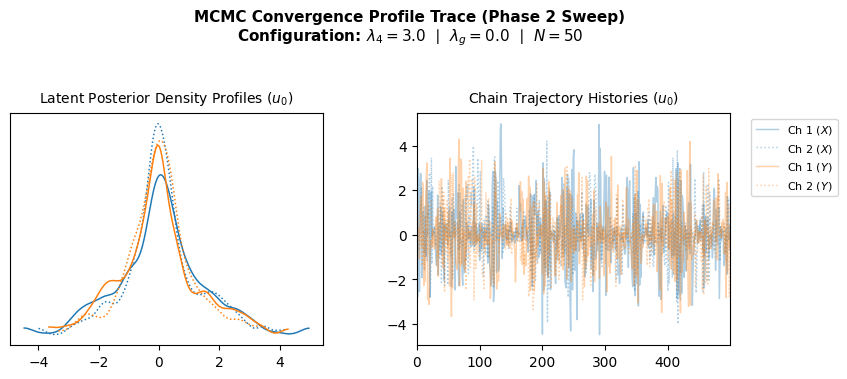


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 0.1 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [03:46,  3.54it/s, step size=4.32e-02, acc. prob=0.808]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [04:24,  3.03it/s, step size=4.58e-02, acc. prob=0.799]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0035
    └─ Minimum Bulk ESS: 698.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0613
  └─ 95th Percentile (q_0.95): 0.2051
  └─ 99th Percentile         : 0.2448

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.47%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2779
  └─ 5th Percentile Gap      : 0.0225
  └─ Star-like Fraction (≤γ) : 10.88%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0013
  └─ Median Pairwise Dist    : 0.9551
  └─ Maximum Pairwise Dist   : 3.7865

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 161.272%


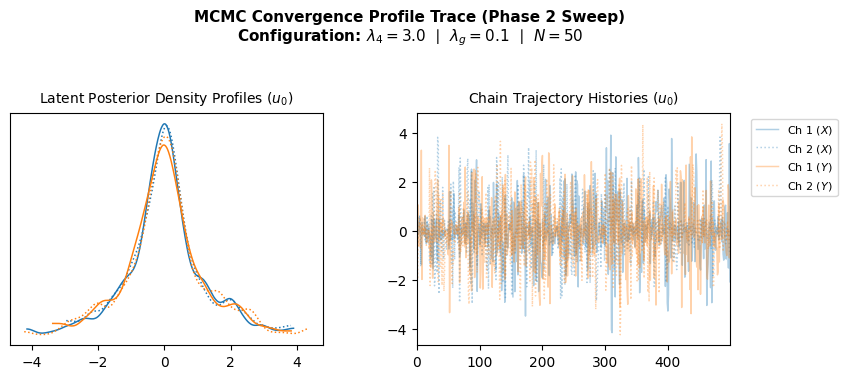


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 0.5 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [03:59,  3.33it/s, step size=4.27e-02, acc. prob=0.813]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [02:56,  4.54it/s, step size=6.04e-02, acc. prob=0.769]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0046
    └─ Minimum Bulk ESS: 265.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0618
  └─ 95th Percentile (q_0.95): 0.2054
  └─ 99th Percentile         : 0.2453

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.34%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2815
  └─ 5th Percentile Gap      : 0.0228
  └─ Star-like Fraction (≤γ) : 10.71%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0038
  └─ Median Pairwise Dist    : 0.9592
  └─ Maximum Pairwise Dist   : 3.5513

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 160.770%


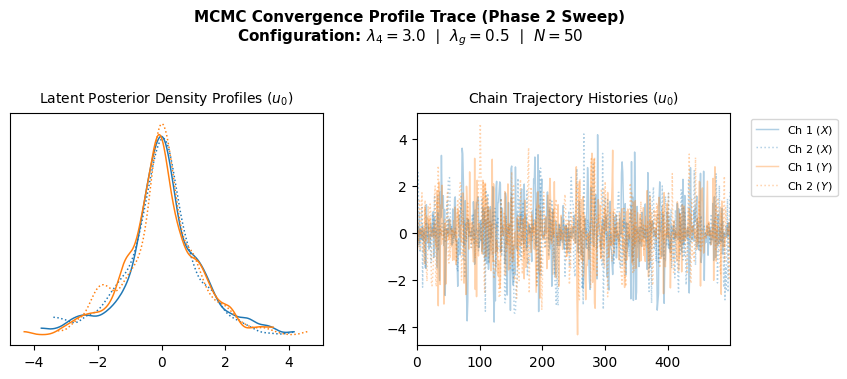


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 1.0 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [04:05,  3.26it/s, step size=3.64e-02, acc. prob=0.832]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [04:10,  3.20it/s, step size=4.13e-02, acc. prob=0.771]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0020
    └─ Minimum Bulk ESS: 561.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0617
  └─ 95th Percentile (q_0.95): 0.2047
  └─ 99th Percentile         : 0.2433

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.30%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2820
  └─ 5th Percentile Gap      : 0.0225
  └─ Star-like Fraction (≤γ) : 10.80%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0024
  └─ Median Pairwise Dist    : 0.9577
  └─ Maximum Pairwise Dist   : 3.5576

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 160.105%


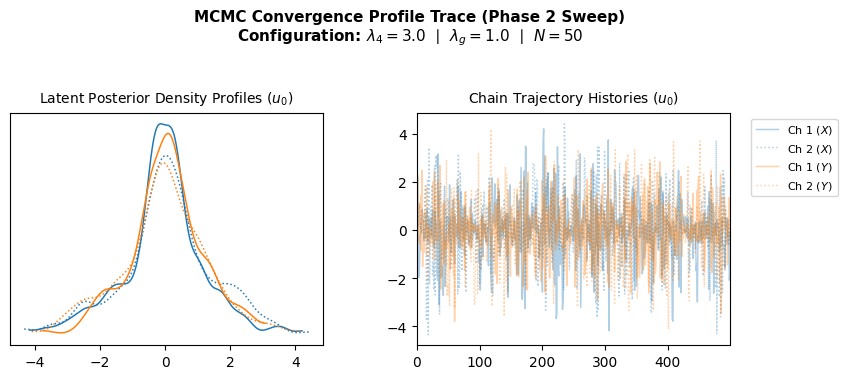


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 2.0 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [04:24,  3.03it/s, step size=3.98e-02, acc. prob=0.747]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [06:04,  2.19it/s, step size=2.61e-02, acc. prob=0.837]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0024
    └─ Minimum Bulk ESS: 510.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0610
  └─ 95th Percentile (q_0.95): 0.2057
  └─ 99th Percentile         : 0.2452

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.60%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2804
  └─ 5th Percentile Gap      : 0.0224
  └─ Star-like Fraction (≤γ) : 10.85%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0024
  └─ Median Pairwise Dist    : 0.9577
  └─ Maximum Pairwise Dist   : 3.6061

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 160.624%


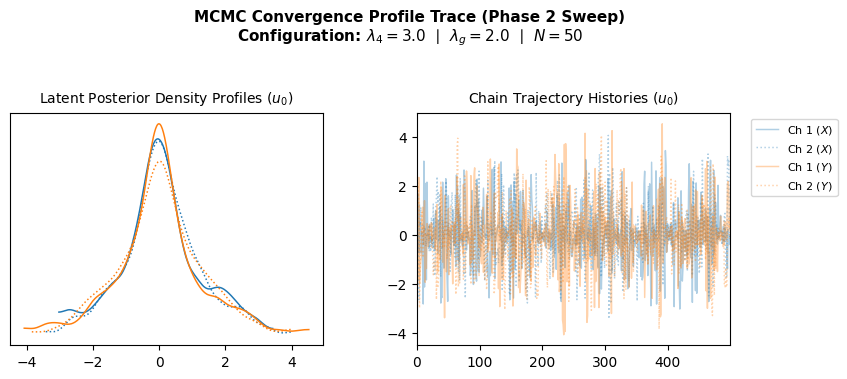


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 5.0 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [09:11,  1.45it/s, step size=1.64e-02, acc. prob=0.820]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [08:43,  1.53it/s, step size=1.76e-02, acc. prob=0.801]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0030
    └─ Minimum Bulk ESS: 522.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0613
  └─ 95th Percentile (q_0.95): 0.2044
  └─ 99th Percentile         : 0.2438

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.70%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2846
  └─ 5th Percentile Gap      : 0.0232
  └─ Star-like Fraction (≤γ) : 10.58%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0027
  └─ Median Pairwise Dist    : 0.9559
  └─ Maximum Pairwise Dist   : 3.4051

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 162.202%


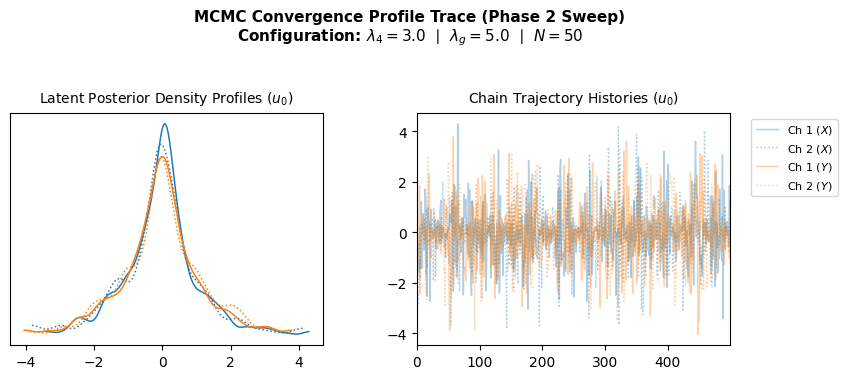


 EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = 3.0 | λg = 10.0 (N=50)
  Running Chain 1/2...


Sample: 100%|██████████| 800/800 [17:06,  1.28s/it, step size=9.14e-03, acc. prob=0.795]


  Running Chain 2/2...


Sample: 100%|██████████| 800/800 [17:24,  1.31s/it, step size=1.08e-02, acc. prob=0.749]


  Merging Phase 2 sequential chains and computing convergence summaries...
    └─ Mean R-hat (Target ≤ 1.05): 1.0017
    └─ Minimum Bulk ESS: 645.0

[1] Hard Four-Point Violations v_q(D~):
  └─ Median Violation        : 0.0612
  └─ 95th Percentile (q_0.95): 0.2052
  └─ 99th Percentile         : 0.2440

[2] Approx Tree-Consistency Rate A(D~; ε=0.05):
  └─ Fraction Consistent     : 43.55%

[3] Quartet Gap Diagnostics g_q(D~):
  └─ Median Branch Gap       : 0.2864
  └─ 5th Percentile Gap      : 0.0232
  └─ Star-like Fraction (≤γ) : 10.47%

[4] Normalized Distance-Scale Diagnostics (Expect Mean=1.0):
  └─ Minimum Pairwise Dist   : 0.0028
  └─ Median Pairwise Dist    : 0.9587
  └─ Maximum Pairwise Dist   : 3.5762

    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): 165.720%


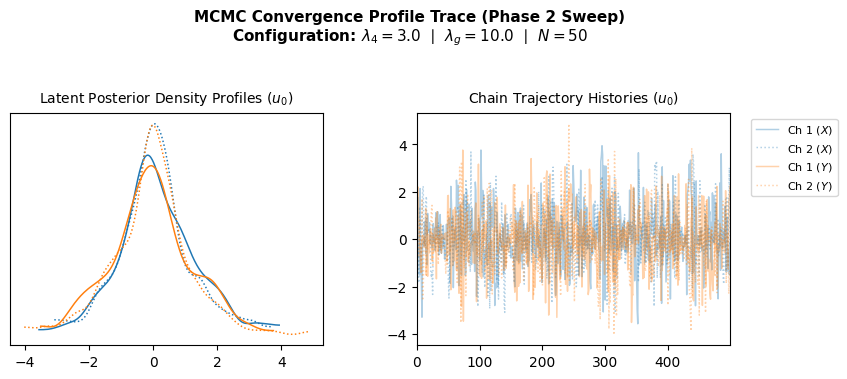

✅ Phase 2 global force sweep completed successfully!


In [32]:
# We fix local force lambda_4 = 3.0 and sweep across lambda_g to open up 
# internal branch gaps while preventing star-tree collapse states.

# Specify the anti-star target grid based on optimization recommendations
lambda_g_grid = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
results_phase2_lg = {}

# Set optimal anchor constraints isolated from Phase 1 analysis
fixed_lmbda_4 = 3.0
target_g0 = 0.1

for lmbda_g in lambda_g_grid:
    print(f"\n EXPERIMENT 1 : Phase 2 (Sequential 2-Chain sweep): λ4 = {fixed_lmbda_4} | λg = {lmbda_g} (N={params['N']})")
    
    # Condition the prior model utilizing both balancing geometric forces
    def phase2_model_conditioned():
        return prior_model.initialize(
            lmbda_4=fixed_lmbda_4,
            lmbda_g=lmbda_g,
            tau=params["tau"],
            use_scale=False,
            g0=target_g0
        )

    chain_idatas = []
    total_divergences = 0
    all_posterior_samples = []

    # Run 2 independent sequential chains to bypass environment multiprocessing traps
    for chain_idx in range(2):
        print(f"  Running Chain {chain_idx + 1}/2...")
        enforce_reproducibility(params["seed"] + chain_idx)

        nuts_kernel = NUTS(
            phase2_model_conditioned, 
            adapt_step_size=True, 
            target_accept_prob=params["target_accept_prob"]
        )
        
        mcmc = MCMC(
            kernel=nuts_kernel,
            num_samples=params["num_samples"],
            warmup_steps=params["warmup_steps"],
            num_chains=1,  
        )
        
        mcmc.run()
        
        # Archive single trace coordinates safely
        chain_idata = az.from_pyro(mcmc, log_likelihood=False)
        chain_idatas.append(chain_idata)
        all_posterior_samples.append(mcmc.get_samples())

        # Collect divergence counts across varying Pyro/ArviZ builds
        div_list = mcmc.diagnostics().get("divergences", [])
        if isinstance(div_list, dict):
            total_divergences += len(div_list.get("chain 0", []))
        else:
            total_divergences += len(div_list) if div_list is not None else 0

    # Combine traces manually to calculate rigorous multi-chain convergence
    print("  Merging Phase 2 sequential chains and computing convergence summaries...")
    idata = az.concat(chain_idatas[0], chain_idatas[1], dim="chain")
    summary_stats = az.summary(idata, var_names=["u"])
    
    mean_rhat = summary_stats["r_hat"].mean()
    min_ess_bulk = summary_stats["ess_bulk"].min()
    
    print(f"    └─ Mean R-hat (Target ≤ 1.05): {mean_rhat:.4f}")
    print(f"    └─ Minimum Bulk ESS: {min_ess_bulk:.1f}")

    # Generate 150 well-spaced draws for downstream metric tracking
    D_samples_list = []
    sample_indices = np.linspace(0, params["num_samples"] - 1, 75, dtype=int)
    
    for chain_samples in all_posterior_samples:
        for s in sample_indices:
            single_sample = {k: v[s:s+1] for k, v in chain_samples.items()}
            try:
                predictive = infer.Predictive(phase2_model_conditioned, posterior_samples=single_sample)
                single_pred = predictive()
                D_matrix = single_pred["D_tilde"].squeeze(0)
                
                if torch.isnan(D_matrix).any() or torch.isinf(D_matrix).any():
                    continue
                    
                D_samples_list.append(D_matrix.detach().cpu().numpy())
            except Exception:
                continue

    if len(D_samples_list) == 0:
        print(f"  Landscape Failure: Complete numerical overflow at λg = {lmbda_g}")
        results_phase2_lg[lmbda_g] = {"metrics": None, "mean_nj_residual": np.nan, "divergences": "ALL"}
        continue
        
    D_samples = torch.stack([
        torch.as_tensor(d, dtype=torch.float32).reshape(params["N"], params["N"]) 
        for d in D_samples_list
    ])

    # Run downstream validation metrics using diagnostics.py module
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
    print_diagnostic_report(metrics, epsilon=0.05, gamma=0.05)
    
    nj_residuals = [compute_nj_residual(D_samples[i]) for i in range(D_samples.shape[0])]
    mean_nj_residual = np.mean(nj_residuals)
    print(f"    └─ Post-hoc Mean NJ Tree Residual R_NJ(D~): {mean_nj_residual * 100:.3f}%")
    
    # Store all values inside the Phase 2 ledger
    results_phase2_lg[lmbda_g] = {
        "metrics": metrics,
        "mean_nj_residual": mean_nj_residual,
        "divergences": total_divergences,
        "arviz_summary": summary_stats,
        "mean_rhat": mean_rhat,
        "min_ess": min_ess_bulk
    }

    # Render MCMC trajectory caterpillar profiles
    axes_grid = az.plot_trace(
        idata, 
        var_names=["u"], 
        coords={"u_dim_0": [0], "u_dim_1": [0, 1]},
        compact=True,
        backend_kwargs={"figsize": (10, 4)}
    )
    axes = axes_grid.flatten()
    
    axes[0].set_title(r"Latent Posterior Density Profiles ($u_{0}$)", fontsize=10, pad=8)
    axes[1].set_title(r"Chain Trajectory Histories ($u_{0}$)", fontsize=10, pad=8)
    axes[1].legend(
        labels=[r"Ch 1 ($X$)", r"Ch 2 ($X$)", r"Ch 1 ($Y$)", r"Ch 2 ($Y$)"],
        loc="upper left", bbox_to_anchor=(1.05, 1.0), fontsize=8, frameon=True
    )
       
    fig = axes[0].get_figure()
    fig.suptitle(
        fr"MCMC Convergence Profile Trace (Phase 2 Sweep)" + "\n" +
        fr"Configuration: $\lambda_4 = {fixed_lmbda_4}$ $\mid$ $\lambda_g = {lmbda_g}$ $\mid$ $N = {params['N']}$", 
        y=1.02, fontsize=11, weight='bold'
    )
    fig.subplots_adjust(top=0.76, bottom=0.18, left=0.10, right=0.82, wspace=0.30)
    plt.show()

print("✅ Phase 2 global force sweep completed successfully!")

# Plots

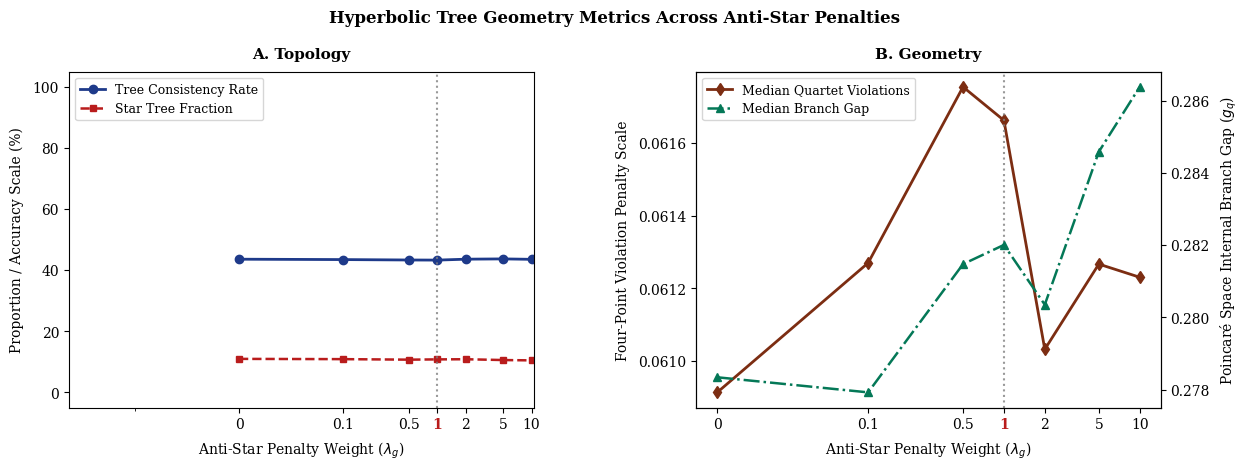

In [53]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'serif'

plot_lgs = []
consistency_rates = []
star_fractions = []
median_violations = []
branch_gaps = []

for lg in lambda_g_grid:
    res = results_phase2_lg.get(lg)
    if res is None or res.get("metrics") is None:
        continue
    
    m = res["metrics"]
    plot_lgs.append(lg)
    
    consistency_rates.append(m.get("tree_consistency_rate", 0.0) * 100)
    
    if "quartet_gap" in m:
        star_fractions.append(m["quartet_gap"].get("unresolved_fraction", 0.0) * 100)
        branch_gaps.append(m["quartet_gap"].get("median", 0.0))
    else:
        star_fractions.append(0.0)
        branch_gaps.append(0.0)
        
    if "hard_violations" in m:
        median_violations.append(m["hard_violations"].get("median", 0.0))
    else:
        median_violations.append(0.0)

# Initialize the horizontal canvas
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(13, 4.8))

# ─────────────────────────────────────────────────────────────────────────
# PANEL 1: TOPOLOGY
# ─────────────────────────────────────────────────────────────────────────
ax1.plot(plot_lgs, consistency_rates, marker='o', color='#1e3a8a', linewidth=2, markersize=6, label="Tree Consistency Rate")
ax1.plot(plot_lgs, star_fractions, marker='s', color='#b91c1c', linewidth=1.8, linestyle='--', markersize=5, label="Star Tree Fraction")

ax1.set_title("A. Topology", fontsize=11, weight='bold', pad=10)
ax1.set_xlabel(r"Anti-Star Penalty Weight ($\lambda_g$)", fontsize=10, labelpad=6)
ax1.set_ylabel("Proportion / Accuracy Scale (%)", fontsize=10, labelpad=6)
ax1.set_ylim(-5, 105)
ax1.legend(loc="best", fontsize=9, frameon=True, facecolor="white", edgecolor="0.8")

# ─────────────────────────────────────────────────────────────────────────
# PANEL 2: GEOMETRY
# ─────────────────────────────────────────────────────────────────────────
color_viol = '#7c2d12'
ax2.plot(plot_lgs, median_violations, marker='d', color=color_viol, linewidth=2, markersize=6, label="Median Quartet Violations")
ax2.set_xlabel(r"Anti-Star Penalty Weight ($\lambda_g$)", fontsize=10, labelpad=6)
ax2.set_ylabel("Four-Point Violation Penalty Scale", fontsize=10, labelpad=6)
ax2.tick_params(axis='y')

ax2_twin = ax2.twinx()
color_gap = '#047857'
ax2_twin.plot(plot_lgs, branch_gaps, marker='^', color=color_gap, linewidth=1.8, linestyle='-.', markersize=6, label="Median Branch Gap")
ax2_twin.set_ylabel(r"Poincaré Space Internal Branch Gap ($g_q$)", fontsize=10, labelpad=6)
ax2_twin.tick_params(axis='y')

ax2.set_title("B. Geometry", fontsize=11, weight='bold', pad=10)

# ─────────────────────────────────────────────────────────────────────────
# GLOBAL CANVAS ADJUSTMENTS, SYMLOG SCALING & AXIS HIGHLIGHTING
# ─────────────────────────────────────────────────────────────────────────
fig.suptitle(
    "Hyperbolic Tree Geometry Metrics Across Anti-Star Penalties",
    y=0.98, fontsize=12, weight='bold'
)

standard_ticks = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

for ax in [ax1, ax2]:
    # 🌟 STEP 1: Turn on Symmetrical Log Scaling
    # linthresh=0.1 means numbers between 0 and 0.1 are treated linearly so 0.0 plots beautifully
    ax.set_xscale('symlog', linthresh=0.1)
    
    # 🌟 STEP 2: Explicitly force your experimental values as the only tick markers
    ax.set_xticks(standard_ticks)
    
    # 🌟 STEP 3: Clean up formatting so scientific notation (10^0) doesn't ruin the axis
    from matplotlib.ticker import FormatStrFormatter
    ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
    
    # Add vertical anchor guide line
    ax.axvline(x=1.0, color='gray', linestyle=':', alpha=0.8, linewidth=1.5)
    
    # Highlight your selected operational anchor (1.0) on the axis line
    labels_obj = ax.get_xticklabels()
    for lbl in labels_obj:
        if lbl.get_text() == '1':
            lbl.set_color('#b91c1c')
            lbl.set_weight('bold')

# Merge legends for the twin axis panel cleanly
lines, labels = ax2.get_legend_handles_labels()
lines_t, labels_t = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines_t, labels + labels_t, loc="best", fontsize=9, frameon=True, facecolor="white", edgecolor="0.8")

fig.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.92, wspace=0.35)

plt.savefig('exp1_phase2_metrics.png', dpi=300, bbox_inches='tight')
plt.show()